# SF₆ field observations in Hvalfjörður

This notebook analyzes the SF₆ (sulfur hexafluoride) tracer observations collected during the July 2024 field trial in Hvalfjörður. SF₆ was released as a passive tracer analogue to study the dispersion and transport in Hvalfjörður

- **Data loading**: Import the combined SF₆, hydrography, and navigation dataset from Excel and convert to an `xarray.Dataset` indexed by date and observation number.
- **Spatial visualization**: Create daily maps showing log-scaled SF₆ concentrations over Hvalfjörður using Cartopy, with land mask overlays for geographic context.
- **Longitudinal analysis**: Bin observations by longitude and compute daily binned-averaged SF₆ profiles to track plume evolution along the fjord axis.
- **Plume diagnostics**: Calculate mass-weighted median plume positions for each day to quantify advection and dispersion rates.

The results from this notebook provide the observational baseline for comparison with ROMS passive dye simulations in `SF6_model-Copy1.ipynb`.

In [ ]:
import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
import seawater as sw
from roms_regrid import *

In [18]:
xls = pd.ExcelFile('/home/x-uheede/R/field_trial/20241119_combined_data.xlsx')


combo = pd.read_excel(xls, '20241119_combined_data',decimal='.')
combo

,Date,Lat,Long,TIMESTAMP,Unnamed: 4,SF6 (fmol/L),Col,Area,TSG_salinity,TSG-temp,Obs_no
0,2024-07-17,64.32825,-21.80205,04:45:00,PM,0.10,R,0.1,33.3366,11.8161,1
1,2024-07-17,64.32976,-21.79768,04:46:00,PM,0.10,L,0.1,33.3808,11.6866,2
2,2024-07-17,64.33173,-21.79222,04:48:00,PM,0.10,R,0.1,33.3917,11.7163,3
3,2024-07-17,64.33325,-21.78762,04:49:00,PM,0.10,L,0.1,33.2175,11.8738,4
4,2024-07-17,64.33526,-21.78227,04:50:00,PM,0.10,R,0.1,33.1928,11.8925,5
...,...,...,...,...,...,...,...,...,...,...,...
2724,2024-07-25,64.29511,-22.05250,06:02:00,PM,3.58,L,1516.6,34.1858,12.9878,2725
2725,2024-07-25,64.29914,-22.06086,06:04:00,PM,6.28,L,2637.9,34.1605,12.9207,2726
2726,2024-07-25,64.30427,-22.06558,06:07:00,PM,4.64,L,1965.5,34.1565,12.9650,2727
2727,2024-07-25,64.30935,-22.07066,06:09:00,PM,4.46,L,1848.6,33.8809,12.9910,2728


In [19]:
obs=xr.Dataset.from_dataframe(combo)
obs=obs.set_index(index=['Date','Obs_no'])
#obs=obs.drop_duplicates('index')
obs=obs.unstack('index')
#obs=obs.rename(name_dict={'mon/day/yr':'time','Depth':'depth','Latitude(¬∞N)':'lat','Longitude(¬∞E)':'lon'})


In [20]:
grid=xr.open_mfdataset('/anvil/projects/x-ees250129/x-uheede/MATLAB/setup_r2r_phys+bgc/1.Make_grid/Iceland3_grid_MAT.nc')
mask=roms_regrid(grid,grid['mask_rho'])

In [21]:
grid

<xarray.Dataset> Size: 18MB
Dimensions:    (one: 1, eta_rho: 386, xi_rho: 642)
Dimensions without coordinates: one, eta_rho, xi_rho
Data variables: (12/14)
    spherical  (one) |S1 1B dask.array<chunksize=(1,), meta=np.ndarray>
    angle      (eta_rho, xi_rho) float64 2MB dask.array<chunksize=(386, 642), meta=np.ndarray>
    h          (eta_rho, xi_rho) float64 2MB dask.array<chunksize=(386, 642), meta=np.ndarray>
    hraw       (eta_rho, xi_rho) float64 2MB dask.array<chunksize=(386, 642), meta=np.ndarray>
    f          (eta_rho, xi_rho) float64 2MB dask.array<chunksize=(386, 642), meta=np.ndarray>
    pm         (eta_rho, xi_rho) float64 2MB dask.array<chunksize=(386, 642), meta=np.ndarray>
    ...         ...
    lat_rho    (eta_rho, xi_rho) float64 2MB dask.array<chunksize=(386, 642), meta=np.ndarray>
    mask_rho   (eta_rho, xi_rho) float64 2MB dask.array<chunksize=(386, 642), meta=np.ndarray>
    tra_lon    (one) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    tra_lat    (one) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    rotate     (one) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    xy_flip    (one) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    Title:    ROMS grid by Easy Grid. Settings: nx: 640 ny: 384 xsize: 32 ysi...
    Date:     09-Oct-2025
    Type:     ROMS grid produced by Easy Grid

In [22]:
import numpy as np

def get_daily_locations(obs_ds):
    dates = obs_ds['Date'].values
    num_days = len(dates)
    num_obs = obs_ds.dims['Obs_no']
    
    # Initialize empty array: (days, obs, 2)
    locations = np.empty((num_days, num_obs, 2))
    
    for i in range(0,num_days):
        lat = obs_ds['Lat'].isel(Date=i).values
        lon = obs_ds['Long'].isel(Date=i).values + 360  # convert to 0–360 range
        locations[i, :, 0] = lat
        locations[i, :, 1] = lon
    
    return locations

# Example usage
locations_array = get_daily_locations(obs)
print("Shape of locations array:", locations_array.shape)  # should be (9, 2729, 2)


Shape of locations array: (9, 2729, 2)


/tmp/ipykernel_485227/1794326622.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_obs = obs_ds.dims['Obs_no']


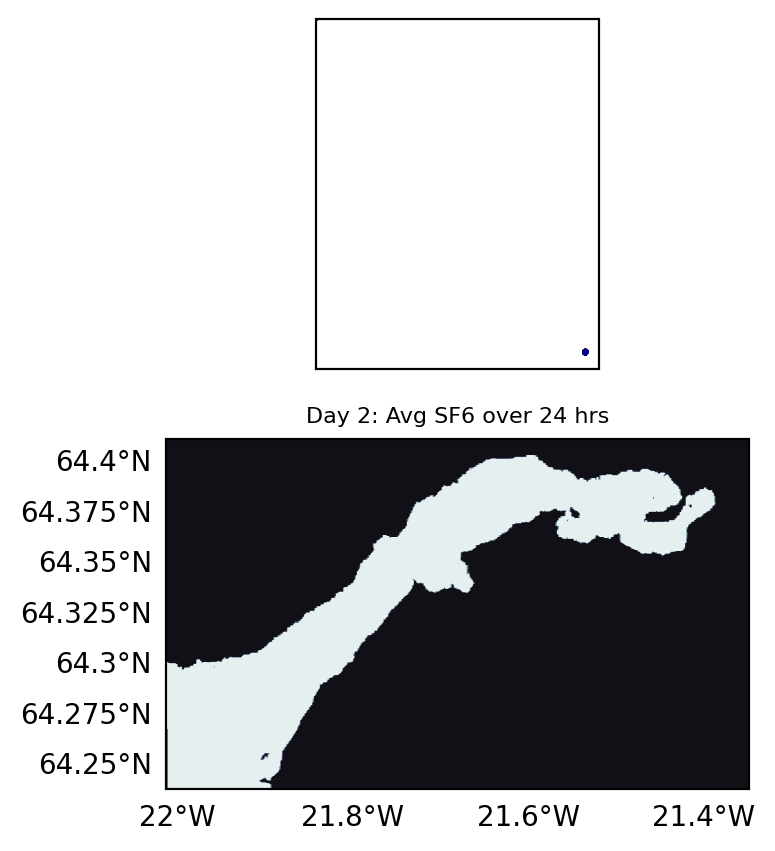

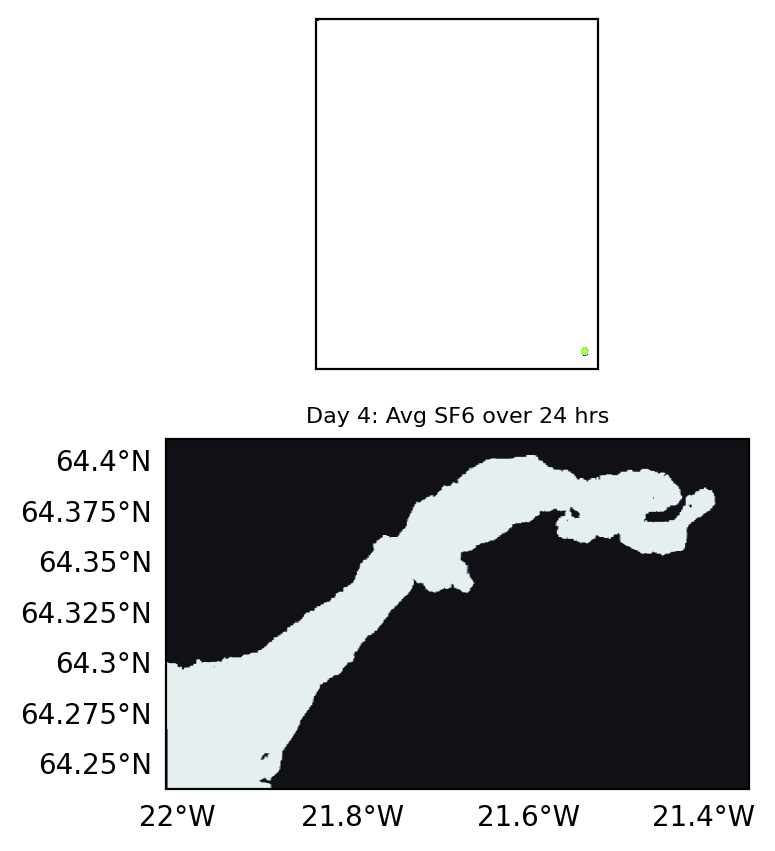

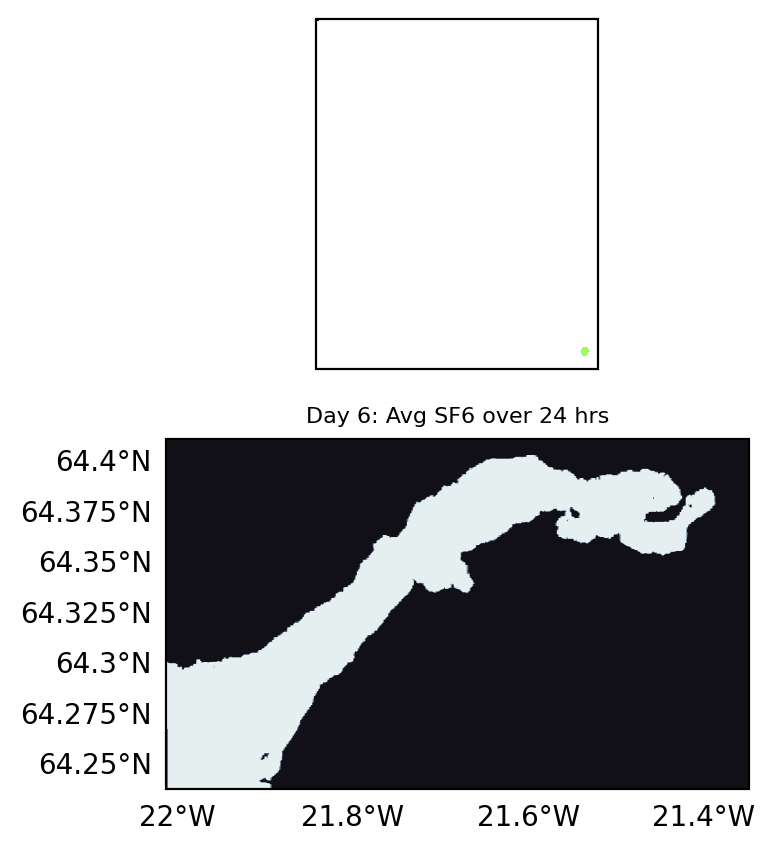

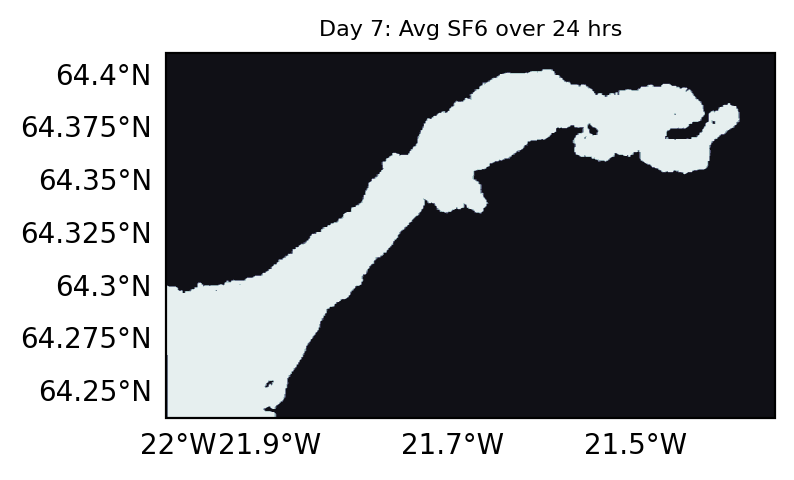

In [23]:
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


figures = [
    {'days': [0, 1]},       # Figure 1: Days 1–2
    {'days': [2, 3]},       # Figure 2: Days 3–4
    {'days': [4, 5]},       # Figure 3: Days 5–6
    {'days': [6]},          # Figure 4: Day 7
]

for fig_idx, group in enumerate(figures):
    nrows = len(group['days'])
    fig, axs = plt.subplots(nrows=nrows, figsize=(6, 2.5 * nrows), dpi=200,
                            subplot_kw={'projection': ccrs.Mercator()})

    if nrows == 1:
        axs = [axs]  # make iterable

    for ax, day in zip(axs, group['days']):
        obs_day=obs['SF6 (fmol/L)'].isel(Date=day).values
        obs_lat=obs['Lat'].isel(Date=day).values
        obs_lon=obs['Long'].isel(Date=day).values
        obs_clear = obs_day[~np.isnan(obs_day)]
        obs_lat = obs_lat[~np.isnan(obs_lat)]
        obs_lon = obs_lon[~np.isnan(obs_lon)]
        
        ax.contourf(mask.lon, mask.lat, mask.load(), transform=ccrs.PlateCarree(), cmap='bone')
        
        scatter = ax.scatter(obs_lat, obs_lon, c=obs_clear, cmap='jet', edgecolor='none',
                             transform=ccrs.PlateCarree(), s=5,
                             norm=LogNorm(vmin=1e-1, vmax=5e4))
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlines = False
    gl.ylines = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    ax.set_title(f'Day {day+1}: Avg SF6 over 24 hrs', fontsize=8)
    # Get the bounding box of the mask
    lon_min = float(mask.lon.min())
    lon_max = float(mask.lon.max())
    lat_min = float(mask.lat.min())
    lat_max = float(mask.lat.max())

    # Set map extent to match mask
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Colorbar
#cbar = ax.colorbar(scatter, ax=axs, orientation='vertical', shrink=0.5, pad=0.05)
#cbar.set_label('SF6 (fmol/L)')

plt.tight_layout()
plt.show()

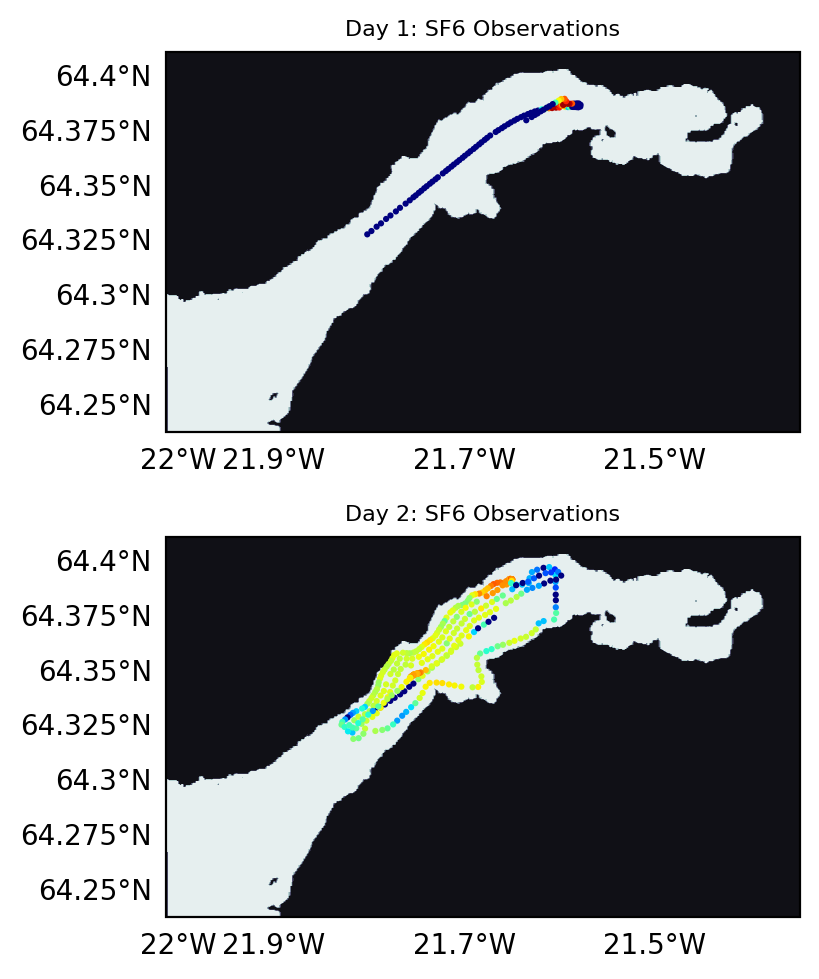

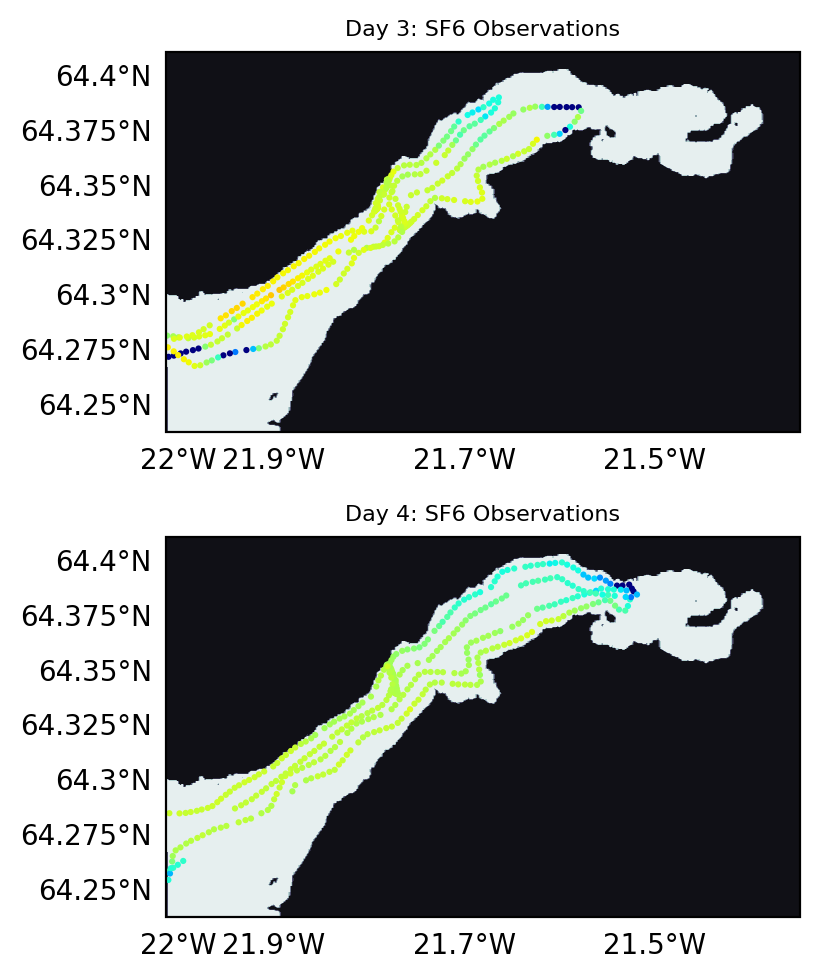

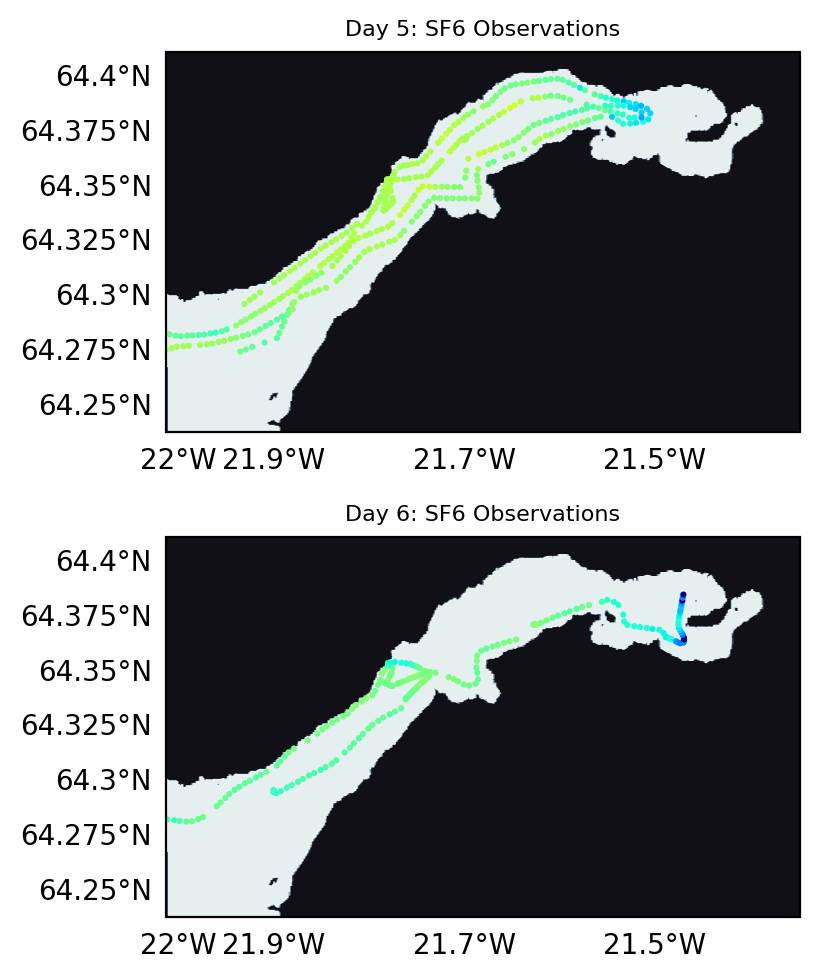

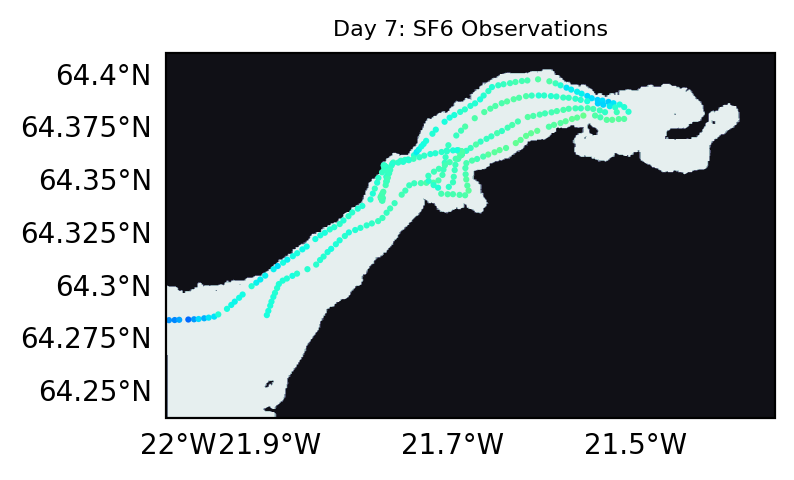

In [24]:
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt

figures = [
    {'days': [0, 1]},       # Figure 1: Days 1–2
    {'days': [2, 3]},       # Figure 2: Days 3–4
    {'days': [4, 5]},       # Figure 3: Days 5–6
    {'days': [6]},          # Figure 4: Day 7
]

for fig_idx, group in enumerate(figures):
    nrows = len(group['days'])
    fig, axs = plt.subplots(nrows=nrows, figsize=(6, 2.5 * nrows), dpi=200,
                            subplot_kw={'projection': ccrs.Mercator()})

    if nrows == 1:
        axs = [axs]  # Make iterable if only one subplot

    for ax, day in zip(axs, group['days']):
        # Extract observation values
        obs_day = obs['SF6 (fmol/L)'].isel(Date=day).values
        obs_lat = obs['Lat'].isel(Date=day).values
        obs_lon = obs['Long'].isel(Date=day).values

        # Remove NaNs
        mask_valid = ~np.isnan(obs_day)
        obs_clear = obs_day[mask_valid]
        obs_lat = obs_lat[mask_valid]
        obs_lon = obs_lon[mask_valid]

        # Plot the land mask
        ax.contourf(mask.lon, mask.lat, mask.load(), transform=ccrs.PlateCarree(), cmap='bone')

        # Plot the observations as scatter points
        scatter = ax.scatter(obs_lon, obs_lat, c=obs_clear, cmap='jet', edgecolor='none',
                             transform=ccrs.PlateCarree(), s=5,
                             norm=LogNorm(vmin=1e-1, vmax=5e4))

        # Set map extent to match mask
        lon_min = float(mask.lon.min())
        lon_max = float(mask.lon.max())
        lat_min = float(mask.lat.min())
        lat_max = float(mask.lat.max())
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        # Add gridlines
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlines = False
        gl.ylines = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

        # Title
        ax.set_title(f'Day {day+1}: SF6 Observations', fontsize=8)

    # Optional colorbar for each figure (shared across subplots)
    # cbar = fig.colorbar(scatter, ax=axs, orientation='vertical', shrink=0.6, pad=0.05)
    # cbar.set_label('SF6 (fmol/L)')

    plt.tight_layout()
    plt.show()


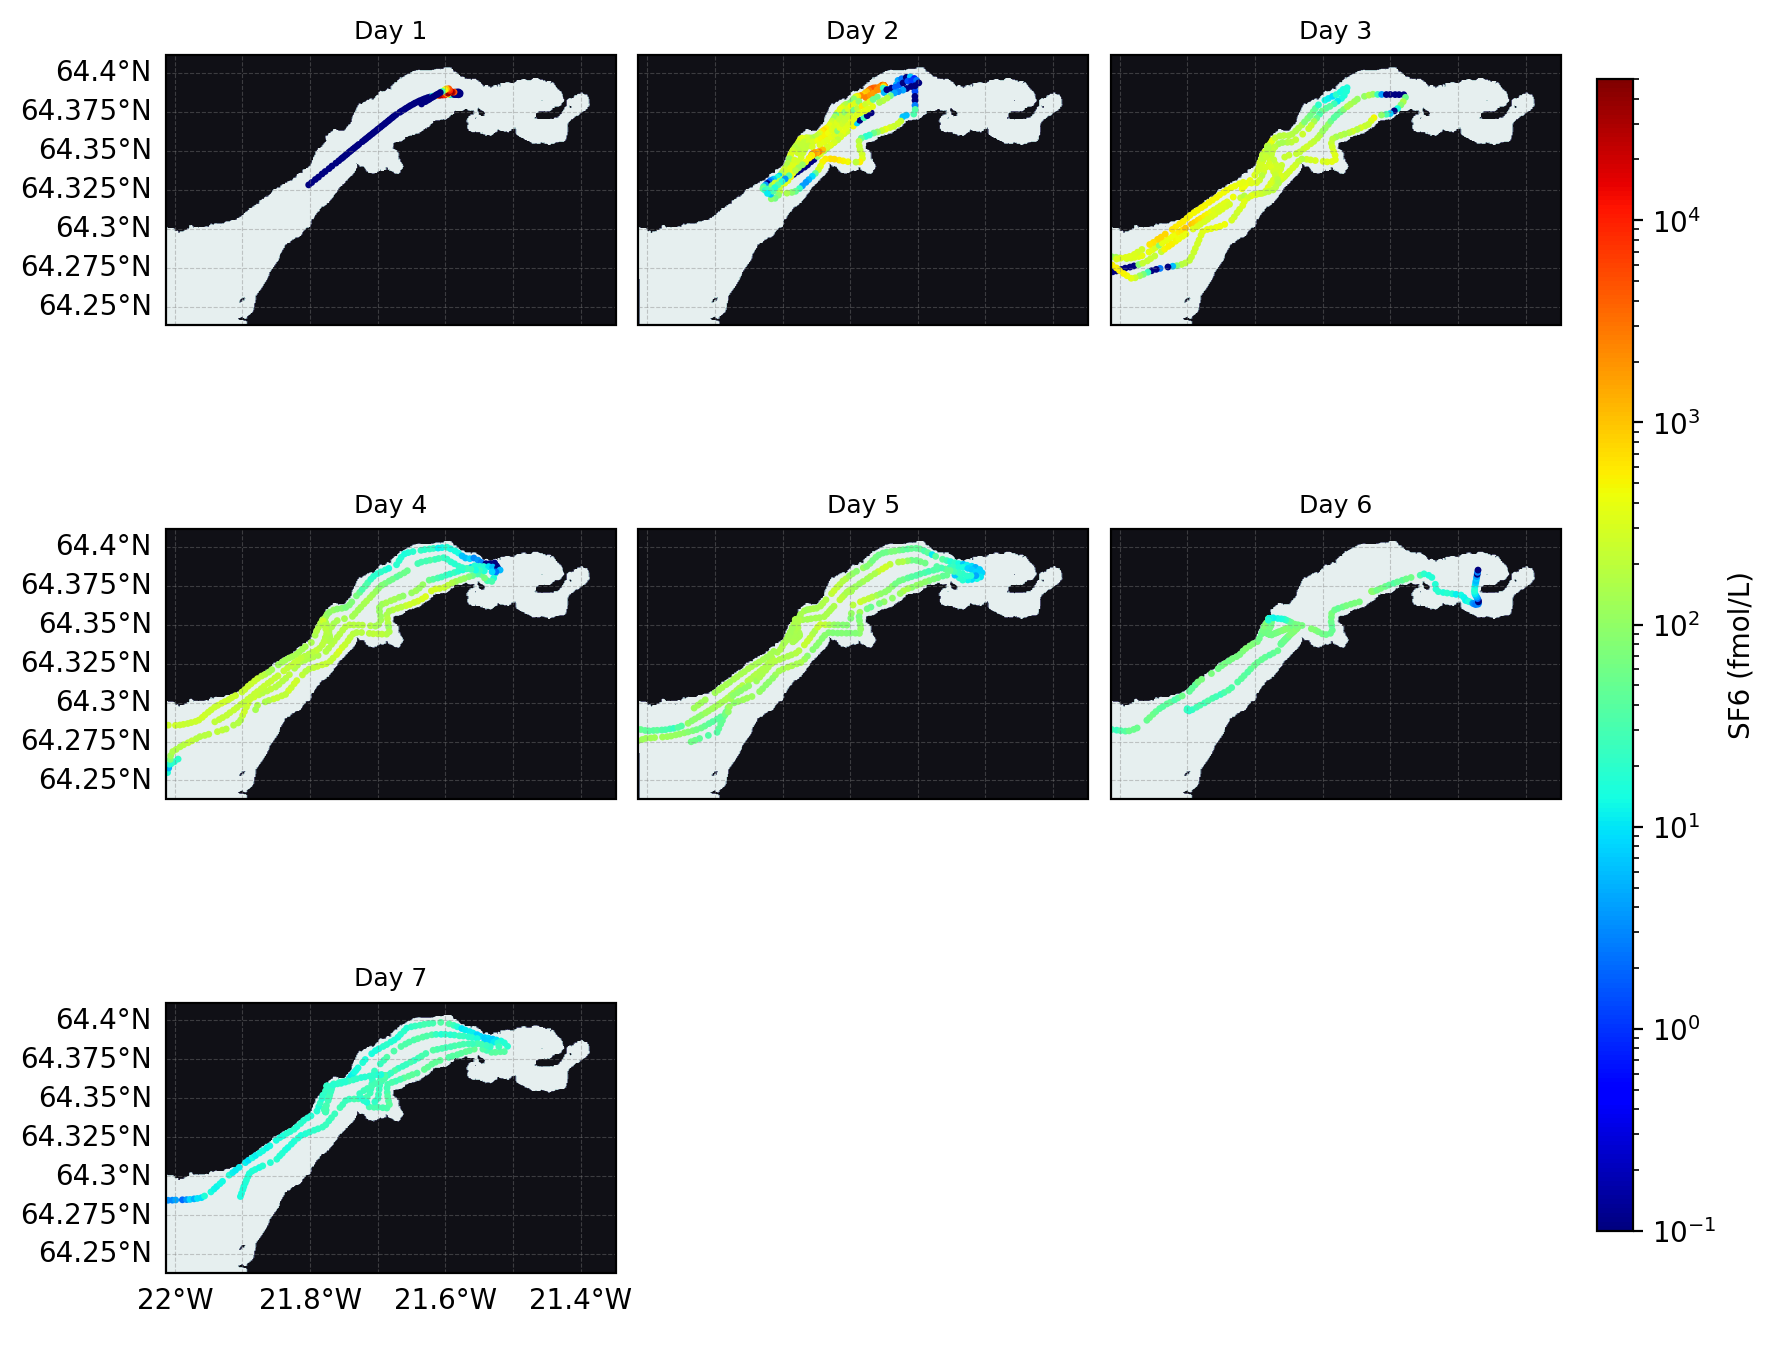

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

days = list(range(7))

fig, axs = plt.subplots(
    nrows=3, ncols=3,
    figsize=(9, 9),
    dpi=200,
    subplot_kw={'projection': ccrs.Mercator()},
    gridspec_kw={'wspace': 0.05, 'hspace': 0.08}   # tighter spacing
)

axs = axs.flatten()

lon_min = float(mask.lon.min())
lon_max = float(mask.lon.max())
lat_min = float(mask.lat.min())
lat_max = float(mask.lat.max())

for i, day in enumerate(days):

    ax = axs[i]

    obs_day = obs['SF6 (fmol/L)'].isel(Date=day).values
    obs_lat = obs['Lat'].isel(Date=day).values
    obs_lon = obs['Long'].isel(Date=day).values

    mask_valid = ~np.isnan(obs_day)
    obs_clear = obs_day[mask_valid]
    obs_lat = obs_lat[mask_valid]
    obs_lon = obs_lon[mask_valid]

    ax.contourf(mask.lon, mask.lat, mask.load(),
                transform=ccrs.PlateCarree(), cmap='bone')

    scatter = ax.scatter(
        obs_lon, obs_lat,
        c=obs_clear,
        cmap='jet',
        edgecolor='none',
        s=6,
        transform=ccrs.PlateCarree(),
        norm=LogNorm(vmin=1e-1, vmax=5e4)
    )

    ax.set_extent([lon_min, lon_max, lat_min, lat_max],
                  crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=False,
                      linewidth=0.4,
                      color='gray',
                      alpha=0.4,
                      linestyle='--')

    if i % 3 == 0:
        gl.left_labels = True
        gl.yformatter = LATITUDE_FORMATTER

    if i >= 6:
        gl.bottom_labels = True
        gl.xformatter = LONGITUDE_FORMATTER

    ax.set_title(f'Day {day+1}', fontsize=9)

# Turn off unused panels
for j in range(len(days), 9):
    axs[j].axis('off')

# -----------------------
# Dedicated colorbar axis
# -----------------------
cax = fig.add_axes([0.92, 0.18, 0.02, 0.64])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cax)
cbar.set_label('SF6 (fmol/L)')

plt.show()

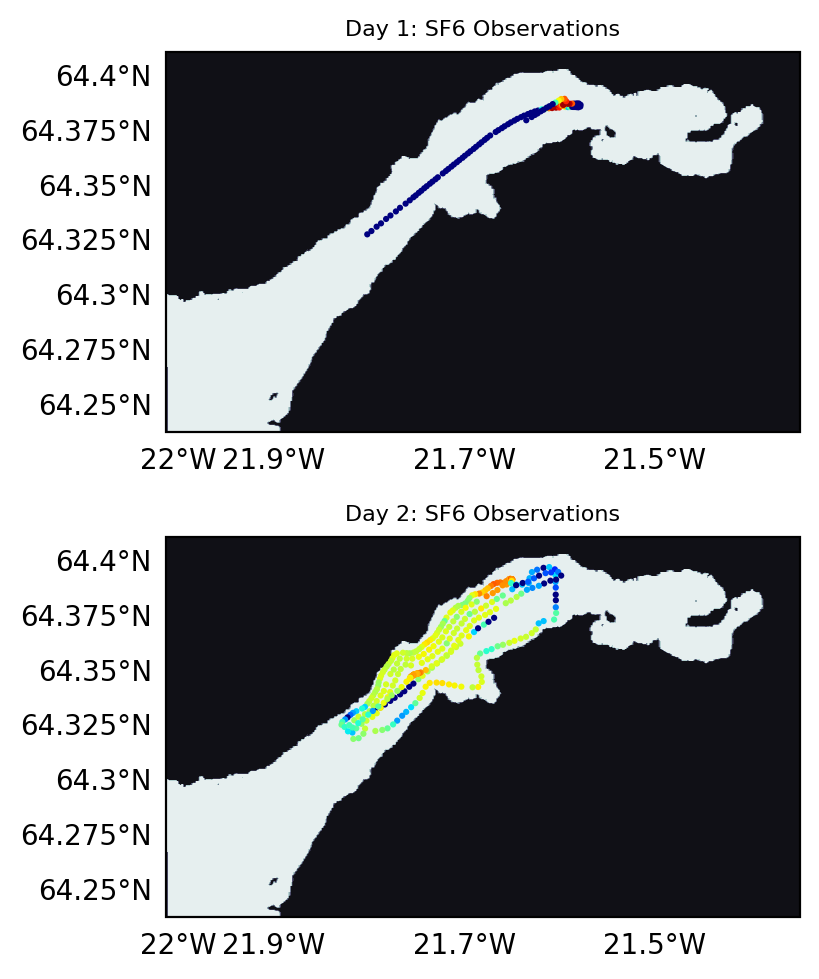

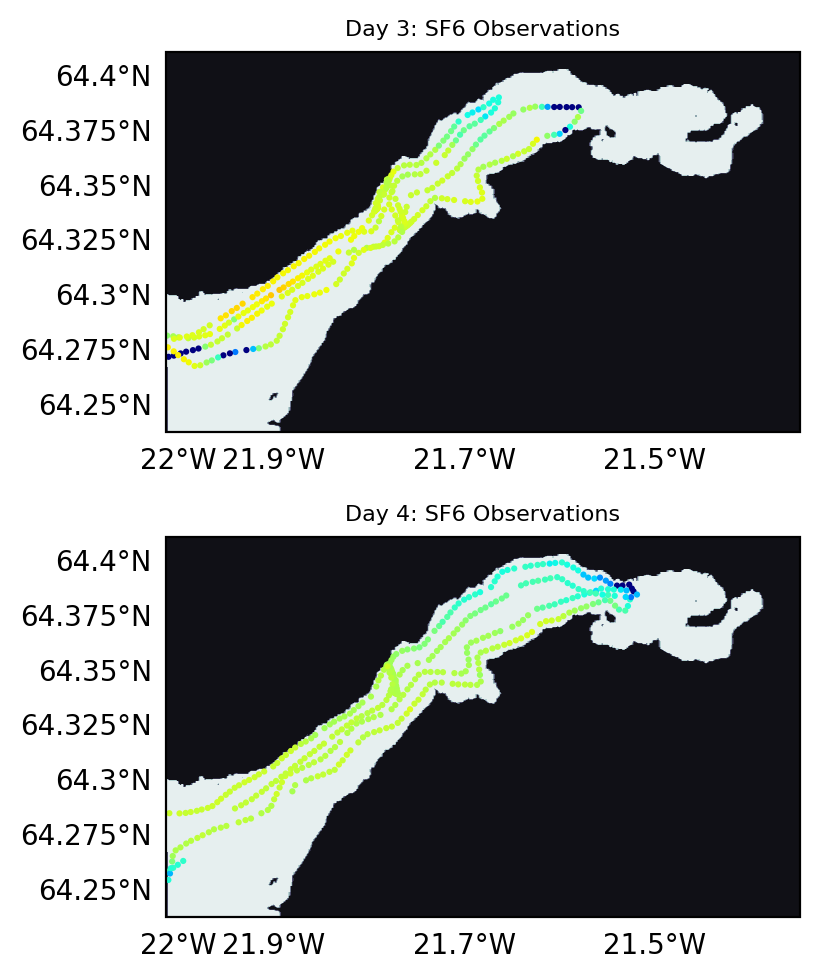

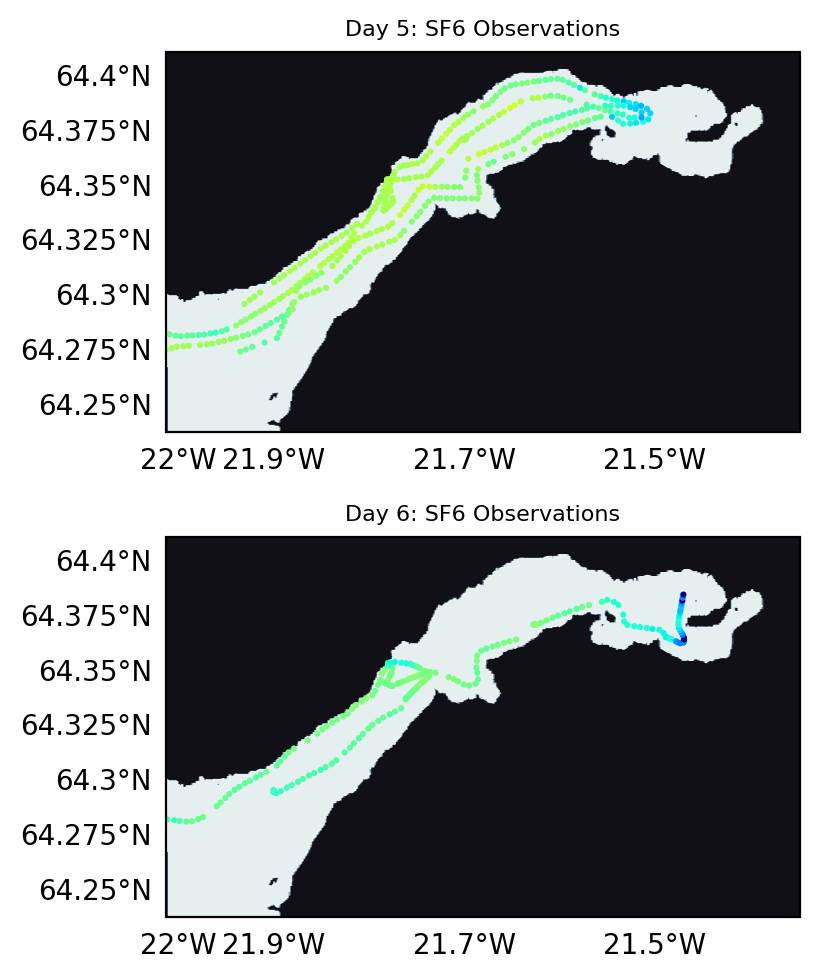

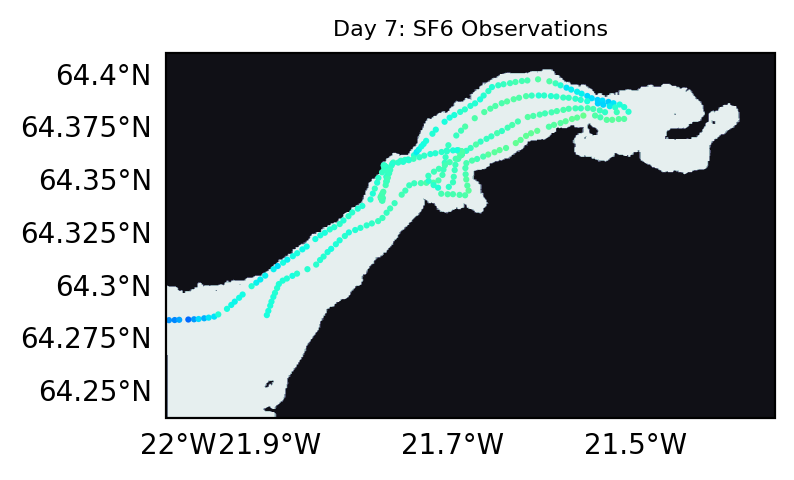

In [26]:
for fig_idx, group in enumerate(figures):
    nrows = len(group['days'])
    fig, axs = plt.subplots(nrows=nrows, figsize=(6, 2.5 * nrows), dpi=200,
                            subplot_kw={'projection': ccrs.Mercator()})

    if nrows == 1:
        axs = [axs]

    all_scatters = []
    for ax, day in zip(axs, group['days']):
        obs_day = obs['SF6 (fmol/L)'].isel(Date=day).values
        obs_lat = obs['Lat'].isel(Date=day).values
        obs_lon = obs['Long'].isel(Date=day).values

        mask_valid = ~np.isnan(obs_day)
        obs_clear = obs_day[mask_valid]
        obs_lat = obs_lat[mask_valid]
        obs_lon = obs_lon[mask_valid]

        ax.contourf(mask.lon, mask.lat, mask.load(), transform=ccrs.PlateCarree(), cmap='bone')

        scatter = ax.scatter(obs_lon, obs_lat, c=obs_clear, cmap='jet', edgecolor='none',
                             transform=ccrs.PlateCarree(), s=5,
                             norm=LogNorm(vmin=1e-1, vmax=5e4))
        all_scatters.append(scatter)

        lon_min = float(mask.lon.min())
        lon_max = float(mask.lon.max())
        lat_min = float(mask.lat.min())
        lat_max = float(mask.lat.max())
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlines = False
        gl.ylines = False
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

        ax.set_title(f'Day {day+1}: SF6 Observations', fontsize=8)

    # Optional: add shared colorbar
    #cbar = fig.colorbar(all_scatters[0], ax=axs, orientation='vertical', shrink=0.6, pad=0.05)
    #cbar.set_label('SF6 (fmol/L)')

    plt.tight_layout()
    plt.savefig(f'sf6_obs_group_{fig_idx+1}.png', dpi=300, bbox_inches='tight')
    plt.show()


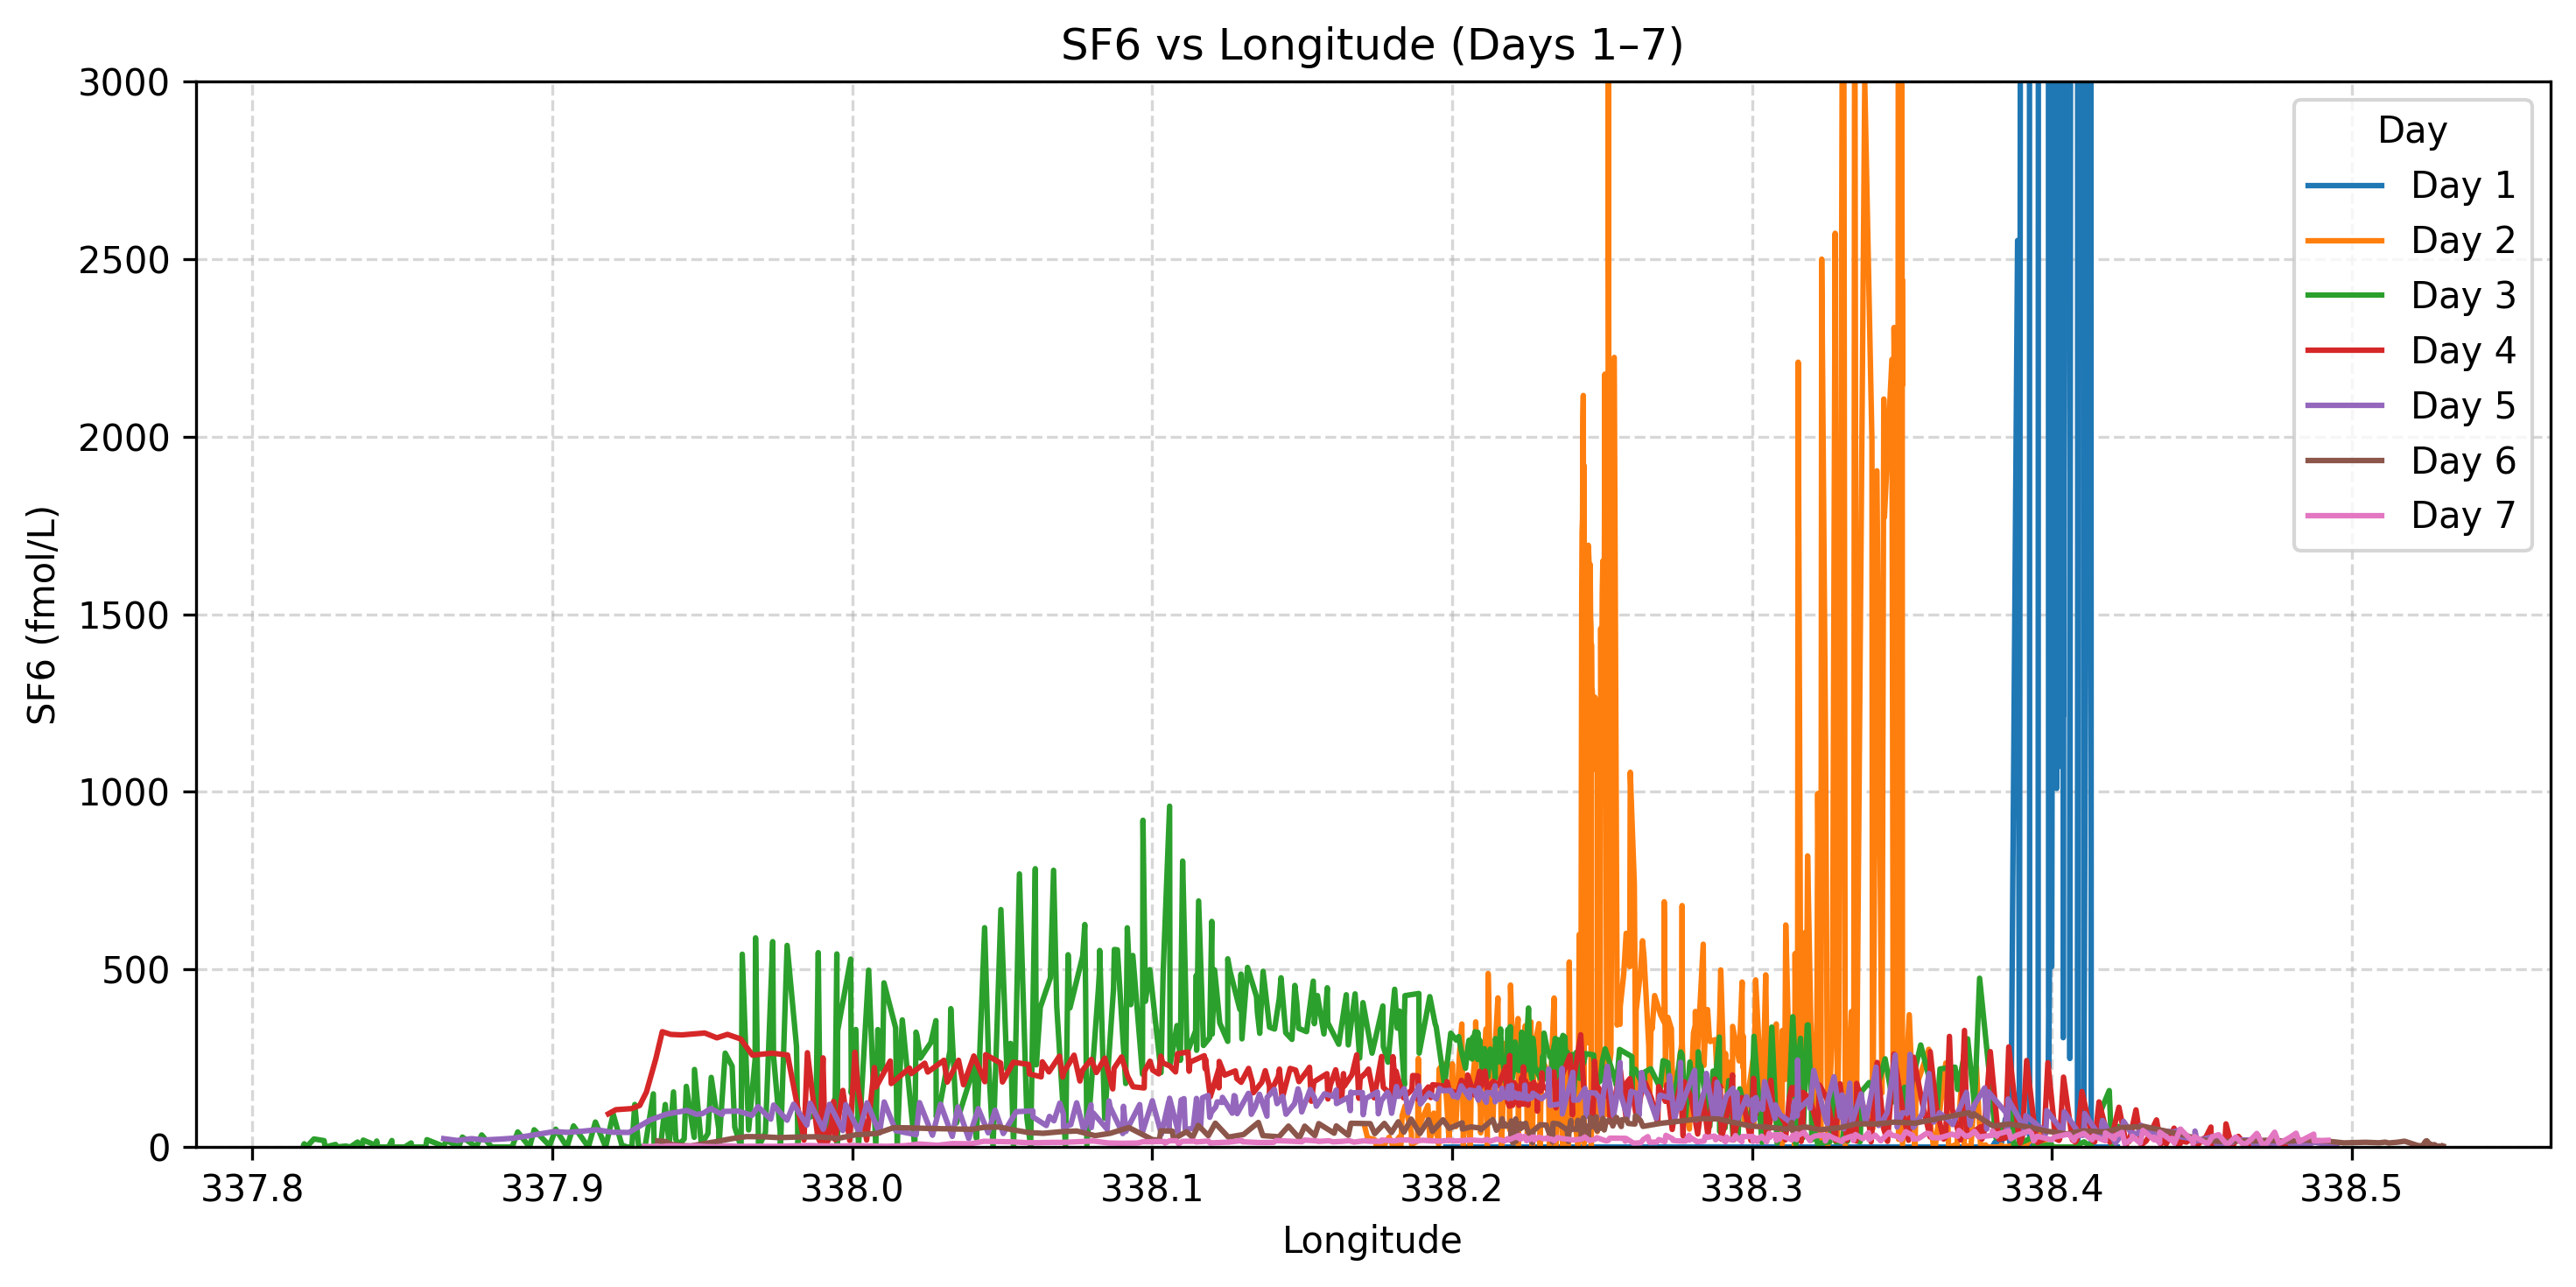

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr



num_days = 7

# Precompute the mask
mask = roms_regrid(grid, grid['mask_rho'])

# Set up plotting
plt.figure(figsize=(10, 5), dpi=300)
vmin, vmax = 1e-1, 5e4

for day in range(num_days):


    obs_day = obs['SF6 (fmol/L)'].isel(Date=day).values
    obs_lat = obs['Lat'].isel(Date=day).values
    obs_lon = obs['Long'].isel(Date=day).values

    mask_valid = ~np.isnan(obs_day)
    obs_clear = obs_day[mask_valid]
    obs_lat = obs_lat[mask_valid]
    obs_lon = obs_lon[mask_valid]

    # Convert to numpy arrays and sort by longitude
    lons = np.array(obs_lon)+360
    dye_values = np.array(obs_clear)
    sort_idx = np.argsort(lons)
    lons_sorted = lons[sort_idx]
    dye_sorted = dye_values[sort_idx]

    # Plot
    plt.plot(lons_sorted, dye_sorted, label=f'Day {day + 1}')

# Final plot formatting
#plt.yscale('log')
plt.xlabel('Longitude')
plt.ylabel('SF6 (fmol/L)')
plt.title('SF6 vs Longitude (Days 1–7)')
plt.legend(title='Day')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.ylim([0,3000])
plt.show()


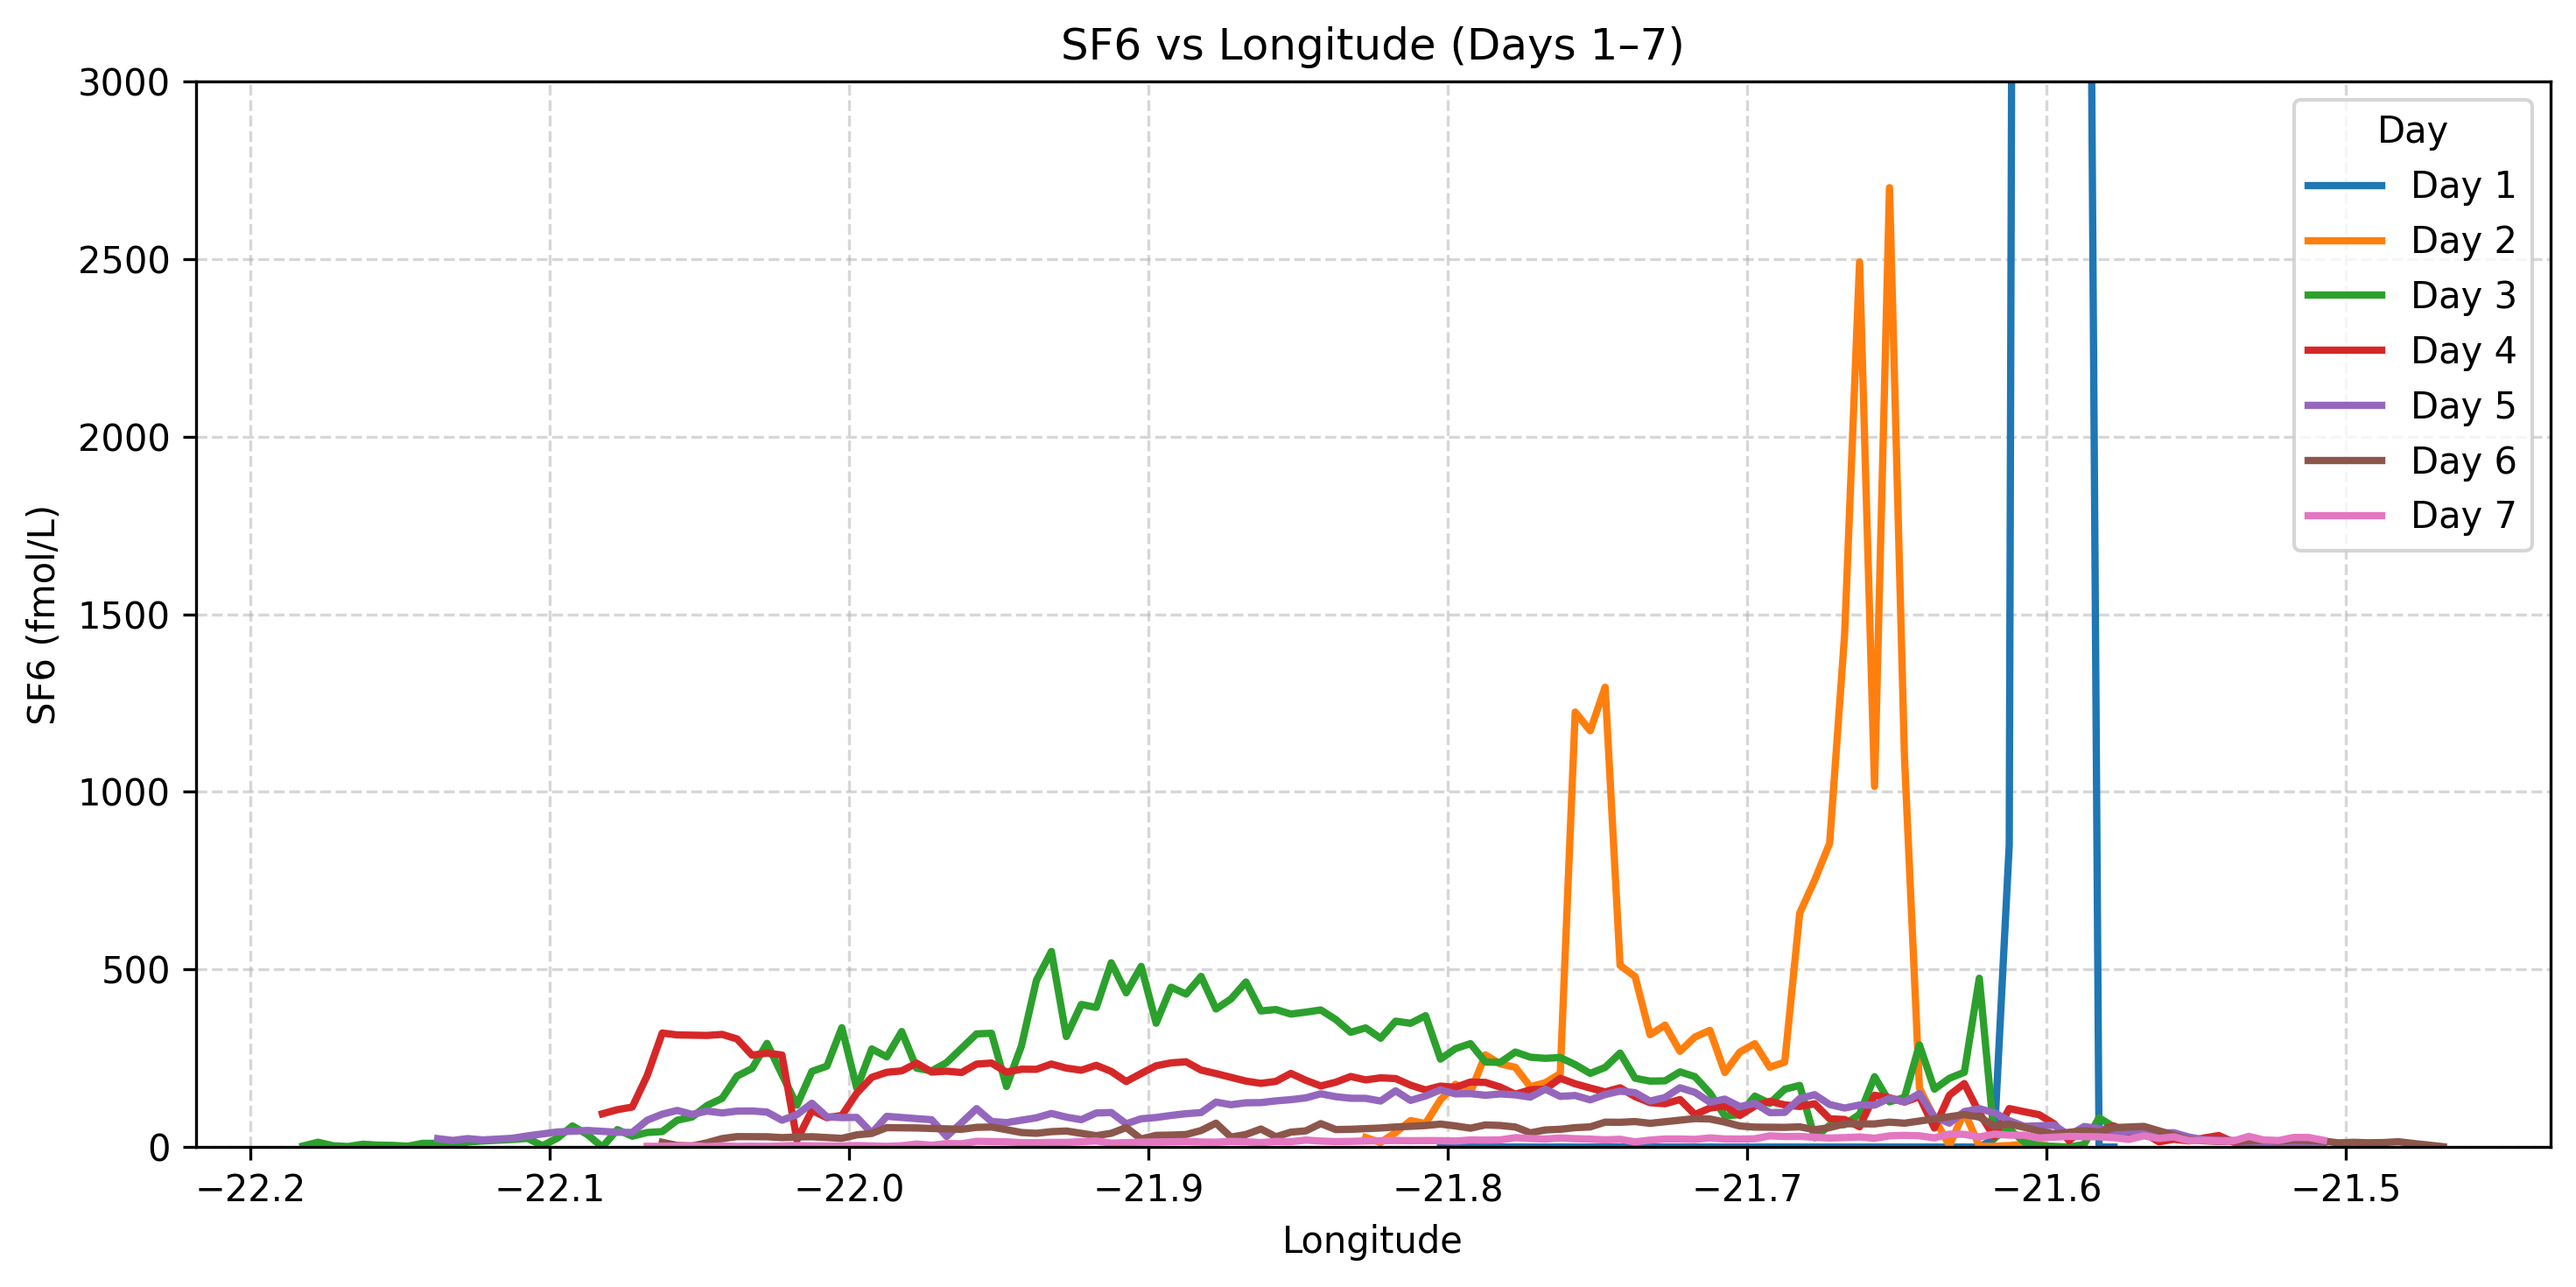

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
mouth_lon=-21.9


num_days = 7

# Precompute the mask
mask = roms_regrid(grid, grid['mask_rho'])

# Set up plotting
plt.figure(figsize=(10, 5), dpi=300)

vmin, vmax = 1e-1, 5e4

bin_width = 0.005  # degrees

for day in range(num_days):

    obs_day = obs['SF6 (fmol/L)'].isel(Date=day).values
    obs_lat = obs['Lat'].isel(Date=day).values
    obs_lon = obs['Long'].isel(Date=day).values

    # -----------------------
    # Clean NaNs
    # -----------------------
    mask_valid = ~np.isnan(obs_day)
    obs_clear = obs_day[mask_valid]
    obs_lon = obs_lon[mask_valid] + 360  # convert to 0–360

    lons = np.array(obs_lon)-360
    dye_values = np.array(obs_clear)

    # -----------------------
    # Define longitude bins
    # -----------------------
    lon_min = np.floor(lons.min() / bin_width) * bin_width
    lon_max = np.ceil(lons.max() / bin_width) * bin_width

    bins = np.arange(lon_min, lon_max + bin_width, bin_width)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Assign points to bins
    bin_idx = np.digitize(lons, bins) - 1

    # -----------------------
    # Bin-averaged SF6
    # -----------------------
    dye_binned = np.full(len(bin_centers), np.nan)

    for i in range(len(bin_centers)):
        in_bin = bin_idx == i
        if np.any(in_bin):
            dye_binned[i] = np.nanmean(dye_values[in_bin])

    # -----------------------
    # Plot continuous line
    # -----------------------
    valid = np.isfinite(dye_binned)

    plt.plot(
        bin_centers[valid],
        dye_binned[valid],
        '-',
        linewidth=2,
        label=f'Day {day + 1}'
    )
    
for ax in [ax1, ax2]:
    ax.axvline(mouth_lon, color='grey', linewidth=3, alpha=0.6, zorder=0)
    
# Final plot formatting
#plt.yscale('log')
plt.xlabel('Longitude')
plt.ylabel('SF6 (fmol/L)')
plt.title('SF6 vs Longitude (Days 1–7)')
plt.legend(title='Day')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.ylim([0,3000])
plt.show()


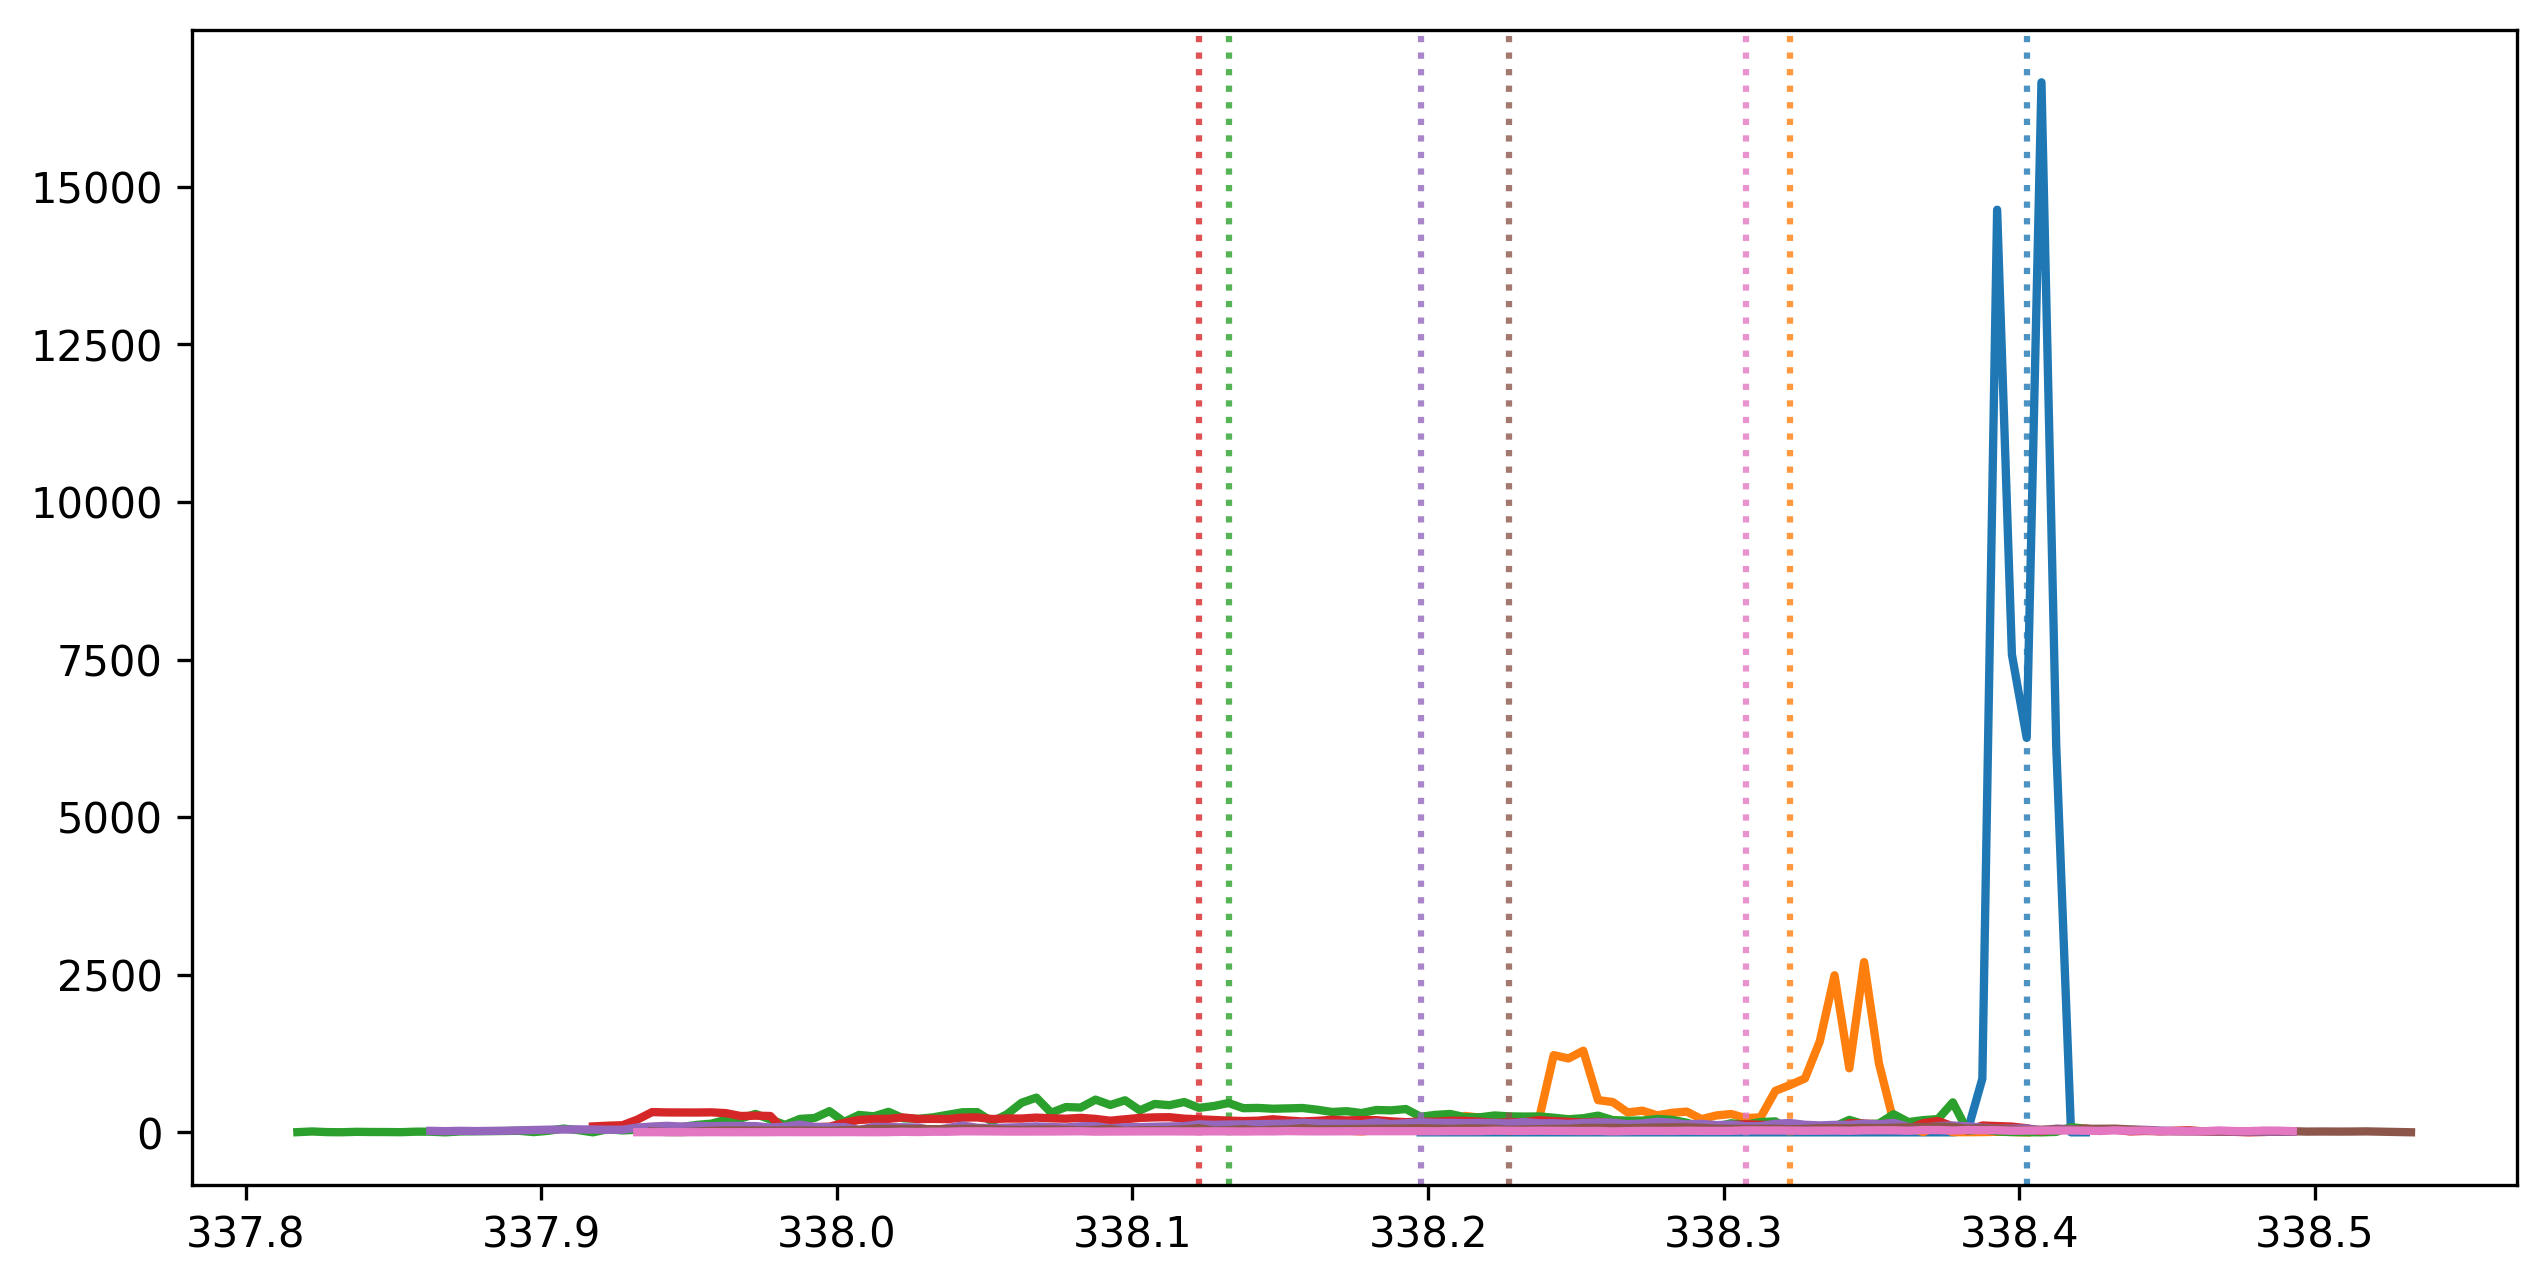

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

num_days = 7

# Set up plotting
plt.figure(figsize=(10, 5), dpi=300)

bin_width = 0.005  # degrees

for day in range(num_days):

    obs_day = obs['SF6 (fmol/L)'].isel(Date=day).values
    obs_lat = obs['Lat'].isel(Date=day).values
    obs_lon = obs['Long'].isel(Date=day).values

    # -----------------------
    # Remove NaNs
    # -----------------------
    mask_valid = ~np.isnan(obs_day)
    obs_clear = obs_day[mask_valid]
    obs_lon = obs_lon[mask_valid] + 360  # convert to 0–360

    lons = np.array(obs_lon)
    dye_values = np.array(obs_clear)

    if len(lons) == 0:
        continue

    # -----------------------
    # Define longitude bins
    # -----------------------
    lon_min = np.floor(lons.min() / bin_width) * bin_width
    lon_max = np.ceil(lons.max() / bin_width) * bin_width

    bins = np.arange(lon_min, lon_max + bin_width, bin_width)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    bin_idx = np.digitize(lons, bins) - 1

    # -----------------------
    # Bin-averaged SF6
    # -----------------------
    dye_binned = np.full(len(bin_centers), np.nan)

    for i in range(len(bin_centers)):
        in_bin = bin_idx == i
        if np.any(in_bin):
            dye_binned[i] = np.nanmean(dye_values[in_bin])

    valid = np.isfinite(dye_binned)

    lon_valid = bin_centers[valid]
    dye_valid = dye_binned[valid]

    if len(lon_valid) == 0:
        continue

    # -----------------------
    # Compute mass-weighted median longitude
    # -----------------------
    weights = dye_valid
    sort_idx = np.argsort(lon_valid)

    lon_sorted = lon_valid[sort_idx]
    w_sorted = weights[sort_idx]

    cumsum = np.cumsum(w_sorted)
    total = cumsum[-1]

    lon_median = lon_sorted[np.searchsorted(cumsum, 0.5 * total)]

    # -----------------------
    # Plot line and median
    # -----------------------
    line, = plt.plot(
        lon_valid,
        dye_valid,
        '-',
        linewidth=2,
        label=f'Day {day + 1}'
    )

    color = line.get_color()

    plt.axvline(
        lon_median,
        linestyle=':',
        linewidth=1.5,
        color=color,
        alpha=0.8
    )




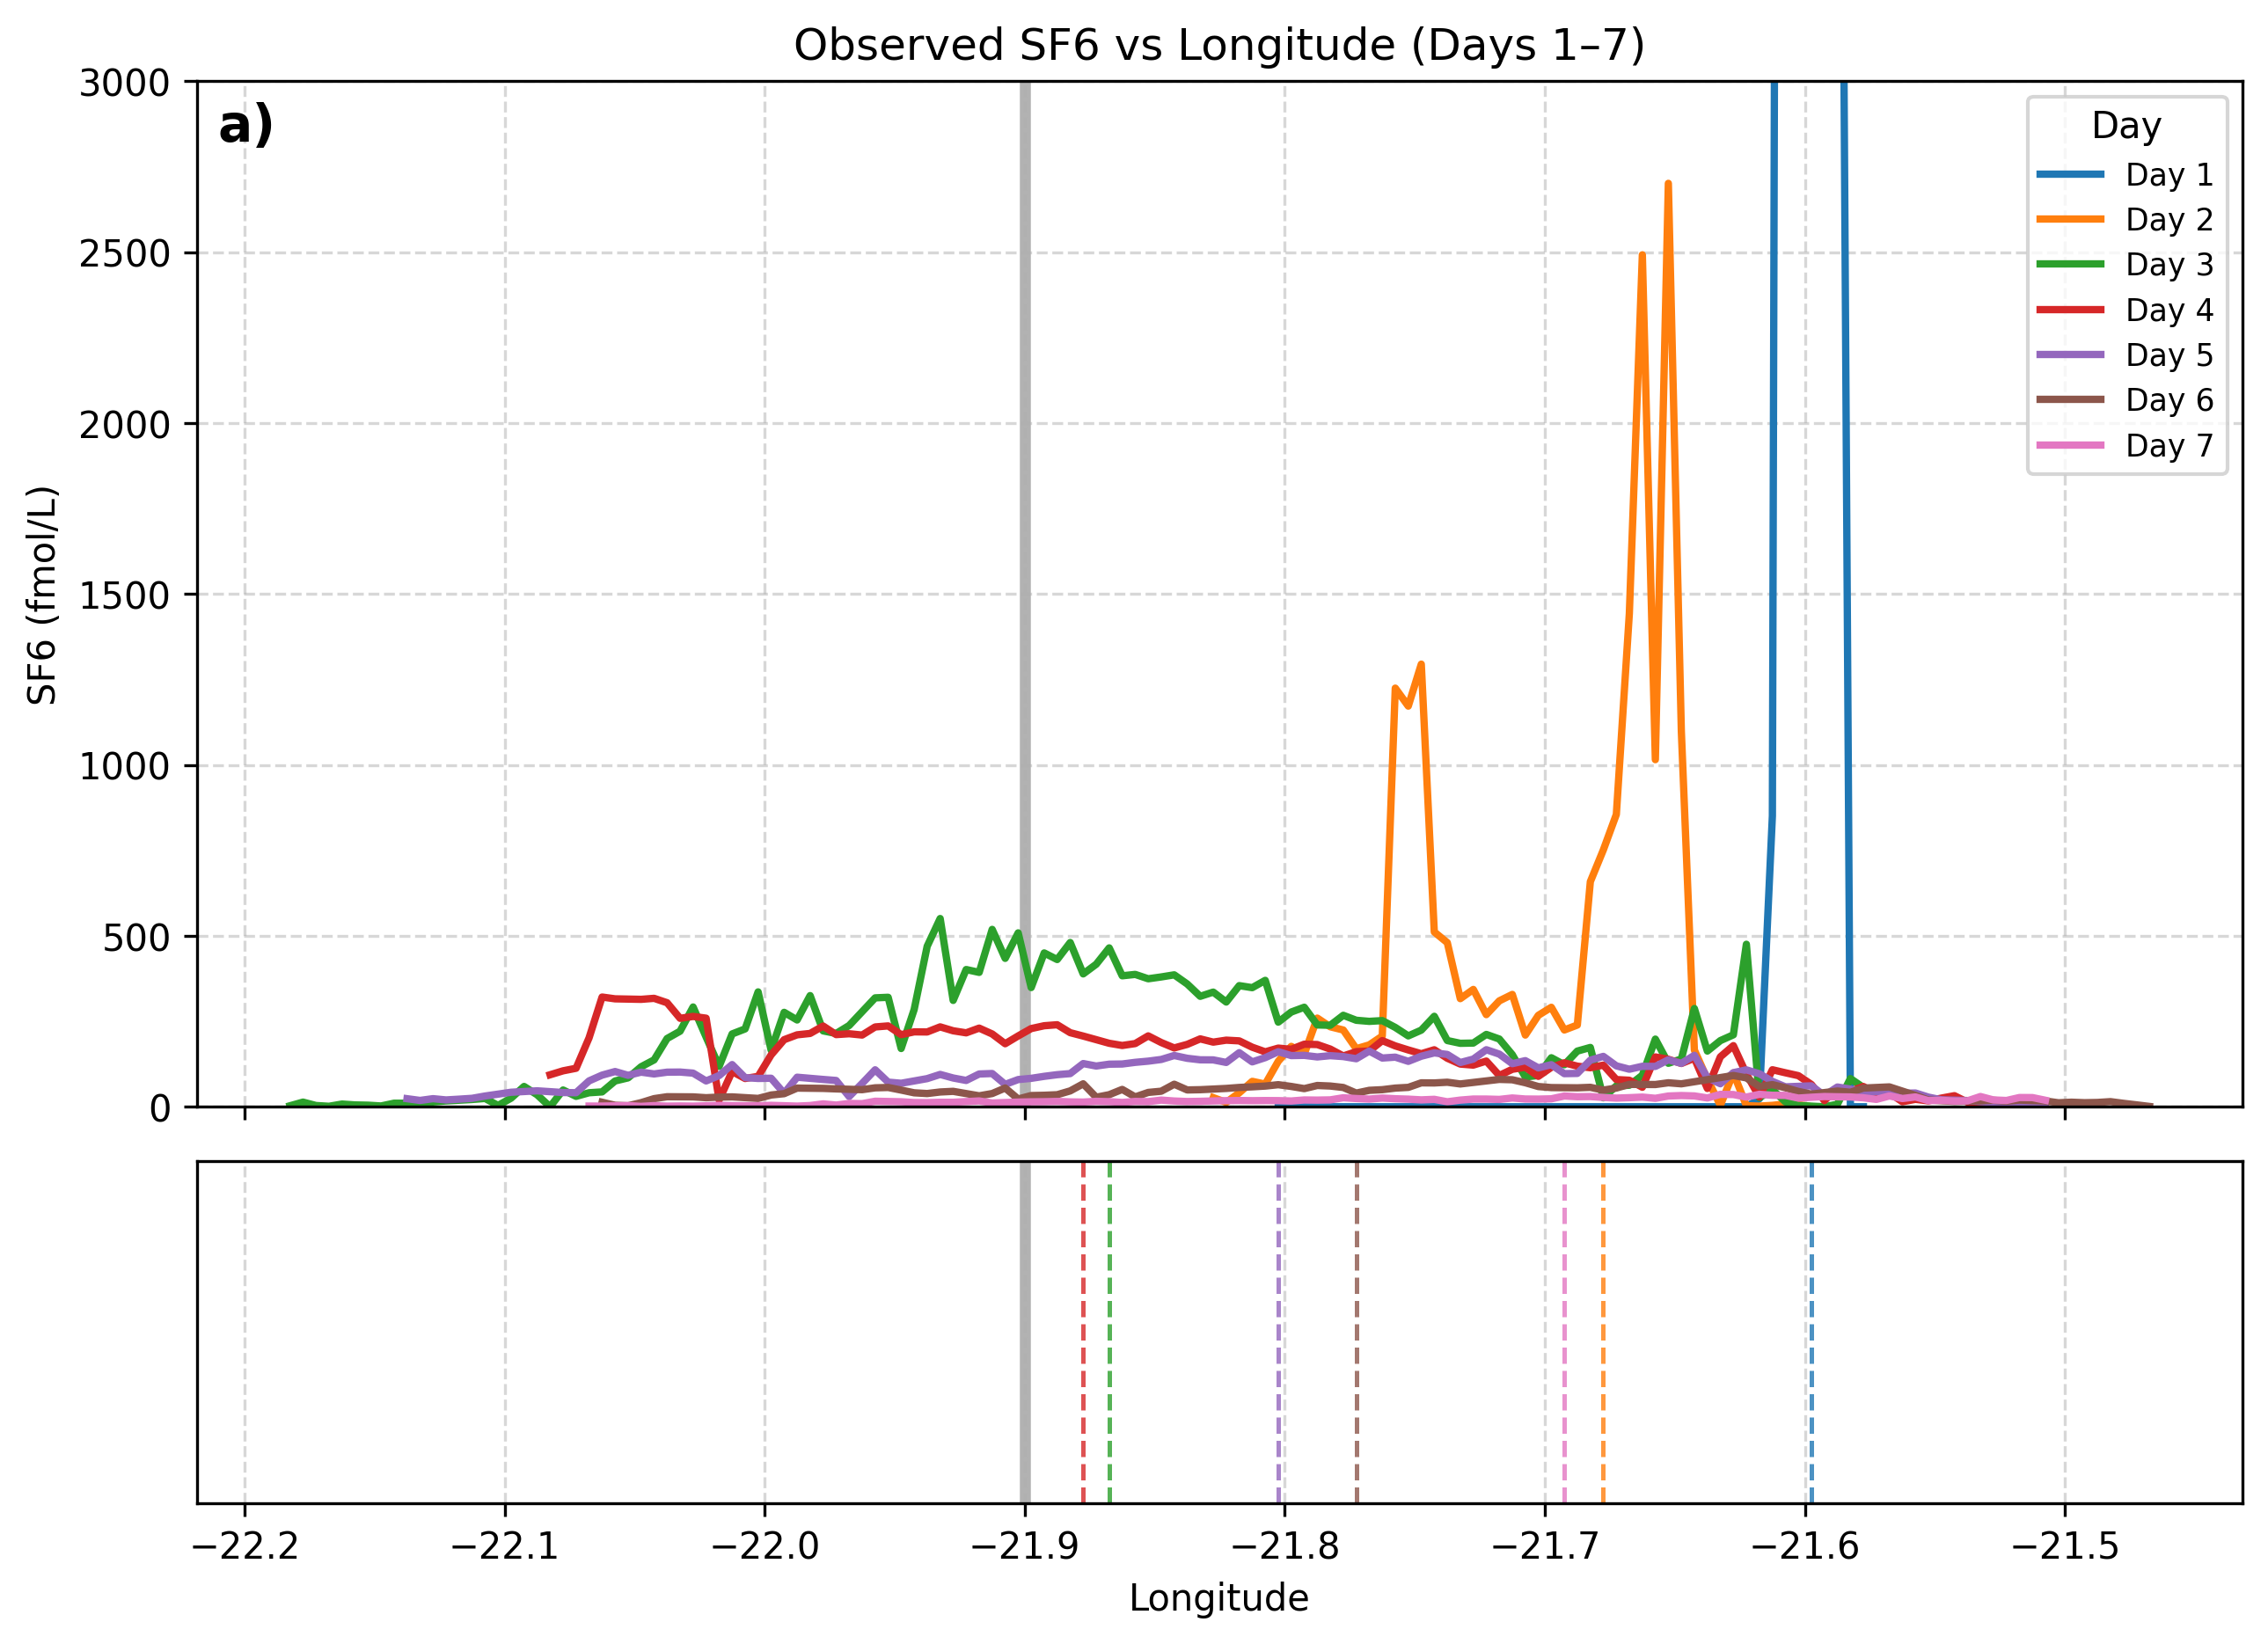

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

num_days = 7
bin_width = 0.005  # degrees
mouth_lon=-21.9
# --- Set up Two-Panel Plotting ---
# sharex=True ensures both plots align perfectly on the longitude axis
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 7), dpi=300, 
                               sharex=True, gridspec_kw={'height_ratios': [3, 1]})

for day in range(num_days):

    obs_day = obs['SF6 (fmol/L)'].isel(Date=day).values
    obs_lat = obs['Lat'].isel(Date=day).values
    obs_lon = obs['Long'].isel(Date=day).values

    # -----------------------
    # Remove NaNs
    # -----------------------
    mask_valid = ~np.isnan(obs_day)
    obs_clear = obs_day[mask_valid]
    obs_lon = obs_lon[mask_valid] + 360  # convert to 0–360

    lons = np.array(obs_lon)-360
    dye_values = np.array(obs_clear)

    if len(lons) == 0:
        continue

    # -----------------------
    # Define longitude bins
    # -----------------------
    lon_min = np.floor(lons.min() / bin_width) * bin_width
    lon_max = np.ceil(lons.max() / bin_width) * bin_width

    bins = np.arange(lon_min, lon_max + bin_width, bin_width)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    bin_idx = np.digitize(lons, bins) - 1

    # -----------------------
    # Bin-averaged SF6
    # -----------------------
    dye_binned = np.full(len(bin_centers), np.nan)

    for i in range(len(bin_centers)):
        in_bin = bin_idx == i
        if np.any(in_bin):
            dye_binned[i] = np.nanmean(dye_values[in_bin])

    valid = np.isfinite(dye_binned)

    lon_valid = bin_centers[valid]
    dye_valid = dye_binned[valid]

    if len(lon_valid) == 0:
        continue

    # -----------------------
    # Compute mass-weighted median longitude
    # -----------------------
    weights = dye_valid
    sort_idx = np.argsort(lon_valid)

    lon_sorted = lon_valid[sort_idx]
    w_sorted = weights[sort_idx]

    cumsum = np.cumsum(w_sorted)
    total = cumsum[-1]

    lon_median = lon_sorted[np.searchsorted(cumsum, 0.5 * total)]

    # -----------------------
    # Plot Main Line (Top Panel)
    # -----------------------
    line, = ax1.plot(
        lon_valid,
        dye_valid,
        '-',
        linewidth=2,
        label=f'Day {day + 1}'
    )

    color = line.get_color()

    # -----------------------
    # Plot Median vertical lines in both panels
    # -----------------------
    # Dotted line in main plot
    #ax1.axvline(lon_median, linestyle=':', linewidth=1.5, color=color, alpha=0.6)
    
    # Dashed line in the empty box
    ax2.axvline(lon_median, linestyle='--', linewidth=1.2, color=color, alpha=0.8)

    # -----------------------
    # Add labels for the medians in the second plot
    # -----------------------
    # Stagger y-position so labels don't overlap if longitudes are close
   # y_pos = [0.8, 0.5, 0.2][day % 3] 
   # ax2.text(
   #     lon_median, y_pos, f'D{day+1}', 
   #     color=color, fontweight='bold',
   #     ha='center', va='center', transform=ax2.get_xaxis_transform()
    #)

# -----------------------
# Final plot formatting
# -----------------------

# Formatting Top Plot (ax1)
ax1.set_ylabel('SF6 (fmol/L)')
ax1.set_title('Observed SF6 vs Longitude (Days 1–7)')
ax1.legend(title='Day', fontsize='small', loc='upper right')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.set_ylim([0, 3000])

# Formatting Bottom Plot (ax2 - The Empty Box)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('')           # Hide ylabel
ax2.set_yticks([])           # Remove y-ticks
ax2.set_yticklabels([])      # Remove y-tick labels
ax2.grid(True, axis='x', linestyle='--', alpha=0.5)

# Panel label a)
ax1.text(
    0.01, 0.98, "a)",
    transform=ax1.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)
for ax in [ax1, ax2]:
    ax.axvline(mouth_lon, color='grey', linewidth=3, alpha=0.6, zorder=0)

# Tighten layout and close the gap between subplots
plt.subplots_adjust(hspace=0.08)
plt.show()